### **<center> Multivariate Gaussian Distribution**

The goal of this task is to synthesize a dataset of $N$ vectors in $L$-dimensional space. These vectors are sampled from a Multivariate Gaussian Distribution characterized by a mean vector $\mu$ and a symmetric, positive semi-definite covariance matrix $\Sigma$.The probability density function for this distribution is defined as:$$N(\mathbf{x}) = \frac{1}{\sqrt{(2\pi)^L |\Sigma|}} \exp\left(-\frac{1}{2}(\mathbf{x}-\mu)^\top \Sigma^{-1} (\mathbf{x}-\mu)\right)$$</center>

In [1]:
import numpy as np

#generates vectors for gaussian function given mean and covariance matrix
def gaussian_generator(mean, covariance, n, L):
    #generating random samples using standard normal
    samples = np.random.randn(n , L)

    #data covariance transformation
    decomp = np.linalg.cholesky(covariance)

    return mean + np.dot(samples, decomp)

### **<center>Gaussian Function Configurations**
<br>    **<center>Function A: Identity Matrix</center>**

This represents a perfectly spherical distribution centered around $\mu = \begin{bmatrix}4 & 0\end{bmatrix}$. The variances are equal, and there is zero correlation between $x_1$ and $x_2$.$$\Sigma_A = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$
<br>
**<center>Function B: Diagonal Matrix</center>**

This represents an elliptical distribution centered around $\mu = \begin{bmatrix}2 & 0\end{bmatrix}$. The variance for $x_2$ (1.85) is higher than $x_1$ (1.2), stretching the distribution, but they remain independent.$$\Sigma_B = \begin{bmatrix} 1.2 & 0 \\ 0 & 1.85 \end{bmatrix}$$
<br>
**<center>Function C: Non-Diagonal Matrix</center>**

This represents a rotated elliptical distribution centered around $\mu = \begin{bmatrix}0 & 0\end{bmatrix}$. Because the off-diagonal elements are non-zero (0.5), the variables are positively correlated.$$\Sigma_C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix}$$</center>

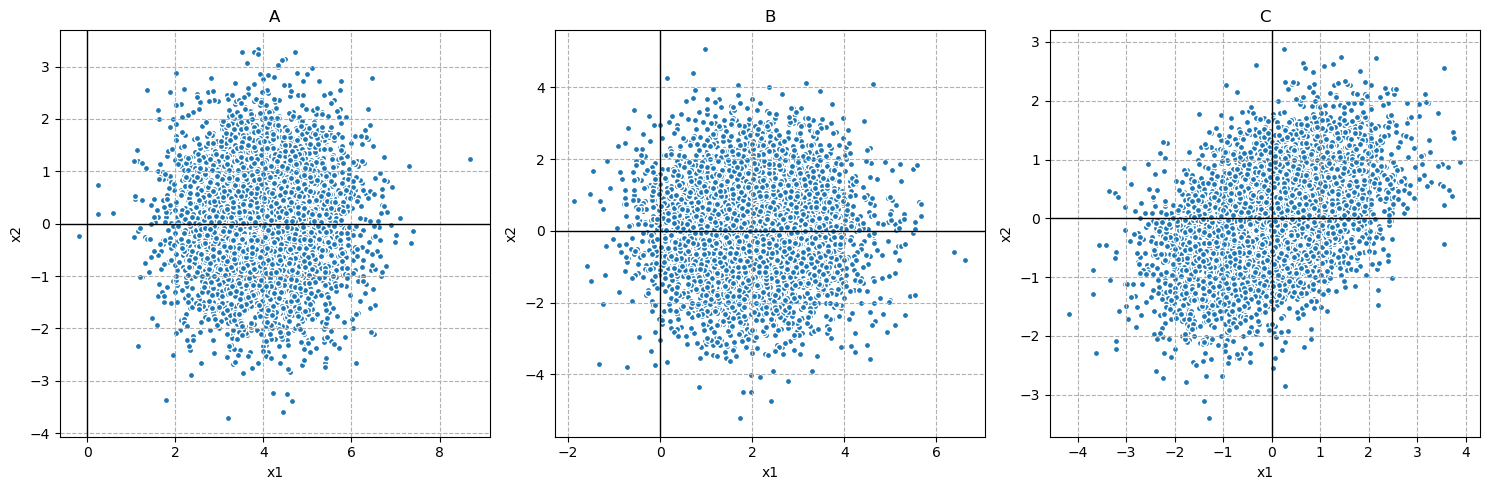

In [2]:
import matplotlib.pyplot as plt

#number of samples
n_samples = 5000

function_a = {"mean": np.array([4, 0]), "covariance" : np.array([[1, 0],[0, 1]]), "label" : 'A'}
function_b = {"mean": np.array([2, 0]), "covariance" : np.array([[1.2, 0], [0, 1.85]]), "label" : 'B'}
function_c = {"mean": np.array([0, 0]), "covariance": np.array([[1, 0.5],[0.5, 1]]), "label" : 'C'}

functions = [function_a, function_b, function_c]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#generate plot for each function case
for i, function in enumerate(functions):
    data = gaussian_generator(function["mean"], function["covariance"], n_samples, 2)

    axes[i].scatter(data[:, 0], data[:, 1], edgecolors='w', s=20)
    axes[i].set_title(function["label"])
    axes[i].set_xlabel('x1')
    axes[i].set_ylabel('x2')
    axes[i].axhline(0, color='black', lw=1)
    axes[i].axvline(0, color='black', lw=1)
    axes[i].grid(True, linestyle='--')

plt.tight_layout()
plt.show()                                   

### **<center>Two-Class Bayesian Classifier**
**Objective:**
The goal of this task is to implement and evaluate a Bayesian Classifier to distinguish between two data distributions. We use samples generated from function A and function C as the two distinct classes (Class A and Class C respectively).

The fundamental goal is to calculate the Posterior Probability, $P(\omega_i | \mathbf{x})$, which represents the probability that the data point belongs to class $\omega_i$ given its features $\mathbf{x}$.According to Bayes' Theorem:$$P(\omega_i | \mathbf{x}) = \frac{p(\mathbf{x} | \omega_i) P(\omega_i)}{p(\mathbf{x})}$$Since the denominator $p(\mathbf{x})$ is the same for all classes when comparing a single data point, we can ignore it for decision-making. We are left with the Decision Function:$$g_i(\mathbf{x}) = p(\mathbf{x} | \omega_i) P(\omega_i)$$
</center>

#### **<center>The Quadratic Discriminant</center>**

Calculating the quadratic discriminant function involves taking the natural log of the function $g_i(\mathbf{x})$ and expanding the likelihood function.We begin with the log of the product of the likelihood and the prior class probability:$$g_i(\mathbf{x}) = \ln(p(\mathbf{x}|\omega_i)P(\omega_i)) = \ln p(\mathbf{x}|\omega_i) + \ln P(\omega_i)$$Substituting the Normal density function $p(\mathbf{x}|\omega_i)$ into the equation:$$p(\mathbf{x} | \omega_i) = \frac{1}{(2\pi)^{L/2} |\Sigma_i|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x}-\mu_i)^\top \Sigma_i^{-1} (\mathbf{x}-\mu_i)\right)$$When we apply the natural logarithm ($\ln$), the properties of logs ($\ln(ab) = \ln a + \ln b$) and the fact that $\ln(e^u) = u$ allow us to break it down:$$\ln p(\mathbf{x} | \omega_i) = \underbrace{-\frac{1}{2}(\mathbf{x}-\mu_i)^\top \Sigma_i^{-1} (\mathbf{x}-\mu_i)}_{\text{Exponent Term}} \underbrace{-\frac{1}{2}\ln|\Sigma_i| - \frac{L}{2}\ln(2\pi)}_{\text{Normalization Constants}}$$By grouping the terms that do not depend on $\mathbf{x}$ into a class-specific constant $c_i$, we arrive at the equation:$$g_i(\mathbf{x}) = -\frac{1}{2}(\mathbf{x}-\mu_i)^\top \Sigma_i^{-1} (\mathbf{x}-\mu_i) + \ln P(\omega_i) + c_i$$Note: In the final implementation, the constant term $-\frac{L}{2}\ln(2\pi)$ is dropped. Since this value is identical for all classes, it does not affect the relative comparison or the final classification decision.

#### **<center>The Linear Discriminant**
For the linear case, we assume that all classes share a common covariance matrix ($\Sigma_i = \Sigma$). Under this assumption, the quadratic terms $\mathbf{x}^\top \Sigma^{-1} \mathbf{x}$ are identical for every class and cancel out during comparison, simplifying the decision boundary to a linear equation.We begin with the simplified log-discriminant function by removing the shared quadratic components and the constant (log-determinant) term:$$g_i(\mathbf{x}) = \mathbf{x}^\top \Sigma^{-1} \mu_i - \frac{1}{2}\mu_i^\top \Sigma^{-1} \mu_i + \ln P(\omega_i)$$Substituting the terms used in the implementation:$$g_i(\mathbf{x}) = \mathbf{w}_i^\top \mathbf{x} + w_{i0}$$Where the weight vector $\mathbf{w}_i$ and the threshold $w_{i0}$ are defined as:$$\mathbf{w}_i = \Sigma^{-1} \mu_i$$$$w_{i0} = -\frac{1}{2}\mu_i^\top \Sigma^{-1} \mu_i + \ln P(\omega_i)$$Note: Just as in the quadratic case, the term $-\frac{L}{2}\ln(2\pi)$ is omitted. Additionally, because the covariance is assumed to be the same across all classes, the constant (the log-determinant $-\frac{1}{2}\ln|\Sigma|$) becomes identical for all classes and is also dropped from the calculation.</center>

In [3]:
def quad_discrim(mean, covariance, x, prior):
    inv_covar = np.linalg.inv(covariance)
    det = np.linalg.det(covariance)
    
    #this gives us (x - µ)
    diff = x-mean

    exp = -0.5*np.dot(np.dot(diff.T, inv_covar), diff)

    #because for the quadratic the covariance is not assumed to be the same, we must account for it
    constant = -0.5 * np.log(det)

    return exp + constant + np.log(prior)

In [4]:
def linear_discrim(mean, covariance, x, prior):
    inv_covar = np.linalg.inv(covariance)

    #no need for determinant this time, the constants cancel out when comparing classes since covar is assumed to be the same
    #this gives us w = Σ⁻¹ μ * x
    wx = np.dot(np.dot(inv_covar, mean), x)

    w_knot = -0.5*np.dot(np.dot(mean.T, inv_covar), mean)

    return wx + w_knot

### **<center>Dataset Generation**
    

Each class has 150 samples generated using the specified Gaussian parameters established in gaussian function configurations section. To prepare the data for classification, we assign labels where Class A is represented by 0 and Class C is represented by 1. The classes are then combined into a single feature matrix $X$ and a target vector $Y$. To ensure an unbiased evaluation of our models, we split the dataset into training and testing subsets using a 70/30 ratio.

**Training Set:** Used to estimate the means, covariances, and prior probabilities.

**Test Set:** Held back to evaluate the model's performance on unseen data.
<br>
<br>
#### **<center>Dataset Parameter Estimation</center>**
The Bayesian classifier relies on parameters estimated directly from the training data:

**Mean ($\mu$):** The average of the features for each class.

**Covariance ($\Sigma$):** The measure of how the features vary together within each class.

**Prior Class Probability ($P(\omega)$):** The probability of each class based on its frequency in the training set.

**Pooled Covariance for LDA:** For the Linear Discriminant Analysis, we assume a shared covariance matrix. This is calculated using a weighted average of the individual class covariances, known as the pooled covariance:$$\Sigma_{LDA} = \frac{(n_A - 1)\Sigma_A + (n_C - 1)\Sigma_C}{n_A + n_C - 2}$$This ensures the decision boundary remains linear by maintaining a consistent "shape" for both distributions.</center>

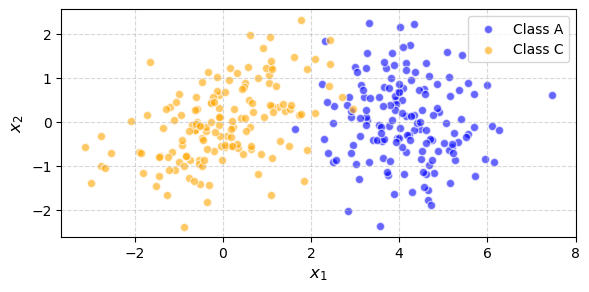

In [5]:
#generating 150 samples from each class
class_a = gaussian_generator(function_a["mean"], function_a["covariance"], 150, 2)
class_c = gaussian_generator(function_c["mean"], function_c["covariance"], 150, 2)

#creating labelsn where class A = 0 and class C = 1
labels_a = np.zeros(150)
labels_c = np.ones(150)

#combine into dataset
X = np.vstack((class_a, class_c))
Y = np.concatenate((labels_a, labels_c))

#visualization of dataset distribution
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

ax.scatter(class_a[:, 0], class_a[:, 1], 
                color='blue', alpha=0.6, label='Class A', edgecolors='w')
ax.scatter(class_c[:, 0], class_c[:, 1], 
                color='orange', alpha=0.6, label='Class C', edgecolors='w')
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

#print(f"Shape of X {X.shape}")
#print(f"Shape of Y {Y.shape}")

#print(X[:5])
#print(Y[:5])

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 13)

#seperate training class
X_train_A = X_train[Y_train == 0]
X_train_C = X_train[Y_train == 1]

#estimating param from training class
mean_A = np.mean(X_train_A, axis=0)
mean_C = np.mean(X_train_C, axis=0)

covar_A = np.cov(X_train_A.T)
covar_C = np.cov(X_train_C.T)

n_a = len(X_train_A)
n_c = len(X_train_C)

prior_A = n_a/len(X_train)
prior_C = n_c/len(X_train)

#covar for the LDA
covar_LDA = ((n_a - 1) * covar_A + (n_c - 1) * covar_C) / (n_a + n_c - 2)

<center>

### **<center>Model Evaluation and Bayesian Classification</center>**

The Bayesian classifier works by assigning an observation x to the class that maximizes the posterior probability. In practice, we use a discriminant function, g 
i
​
 (x), to calculate a specific "score" for each class based on the likelihood of the data and our prior knowledge.

The decision rule is based on a simple comparison:

Assign x to Class A if the score for A is higher than the score for C; otherwise, assign it to Class C.

### **<center>Implementation Process</center>**

To evaluate the performance of our models, we process every sample in the test set through two different analysis fucntions:

**Quadratic Discriminant Analysis (QDA):** This approach uses the covariance matrix estimated for each individual class. By accounting for the specific shape and orientation of each distribution, the model can generate a curved decision boundary that better fits the data.

**Linear Discriminant Analysis (LDA):** This approach assumes that all classes share a single, pooled covariance matrix. By forcing a uniform shape across both groups, the resulting decision boundary is a straight line.

By comparing the scores produced by these functions for every test point, we generate a set of predicted labels. These predictions are then compared against the true labels to determine how well the models classify new data.

</center>

In [7]:
y_pred_qda = []
y_pred_lda = []

#QDA evaluation on test set
for x in X_test:
    score_A_qda = quad_discrim(mean_A, covar_A, x, prior_A)
    score_C_qda = quad_discrim(mean_C, covar_C, x, prior_C)

    score_A_lda = linear_discrim(mean_A, covar_LDA, x, prior_A)
    score_C_lda = linear_discrim(mean_C, covar_LDA, x, prior_C)

    if score_A_qda > score_C_qda:
        y_pred_qda.append(0)
    else:
        y_pred_qda.append(1)

    if score_A_lda > score_C_lda:
        y_pred_lda.append(0)
    else:
        y_pred_lda.append(1)

y_pred_qda = np.array(y_pred_qda)
y_pred_lda = np.array(y_pred_lda)

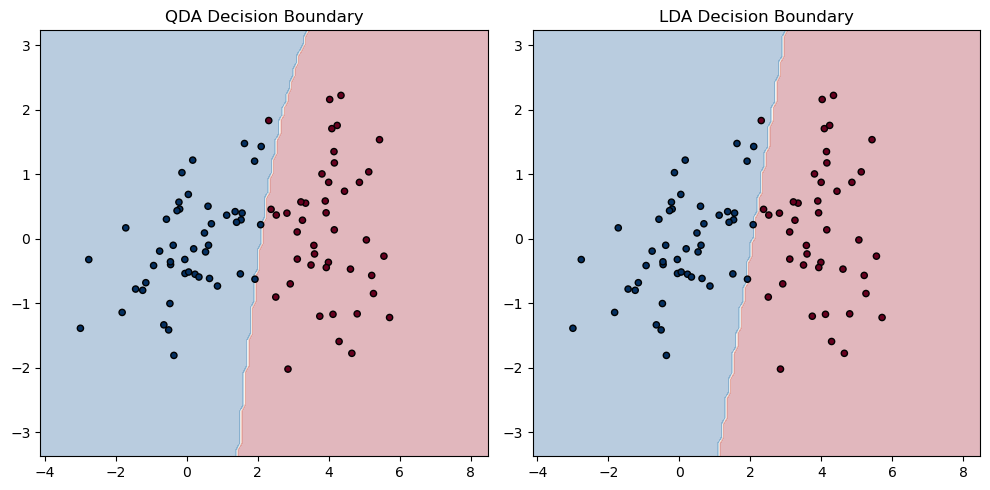

In [12]:
#plotting test data set with descision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

grid_points = np.c_[xx.ravel(), yy.ravel()]

qda = []
lda = []

for point in grid_points:
    #QDA
    sample_aq = quad_discrim(mean_A, covar_A, p, prior_A)
    sample_cq = quad_discrim(mean_C, covar_C, p, prior_C)
    qda.append(0 if sample_aq > sample_cq else 1)
    
    # LDA scores
    sample_al = linear_discrim(mean_A, covar_LDA, p, prior_A)
    sample_cl = linear_discrim(mean_C, covar_LDA, p, prior_C)
    lda.append(0 if sample_al > sample_cl else 1)

qda = np.array(Z_qda).reshape(xx.shape)
lda = np.array(Z_lda).reshape(xx.shape)

plt.figure(figsize=(10, 5))

#QDA plot
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z_qda, alpha=0.3, cmap='RdBu')
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolors='k', s=20, cmap='RdBu')
plt.title("QDA Decision Boundary")

#LDA plot
plt.subplot(1, 2, 2)
plt.contourf(xx, yy, Z_lda, alpha=0.3, cmap='RdBu')
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_test, edgecolors='k', s=20, cmap='RdBu')
plt.title("LDA Decision Boundary")

plt.tight_layout()
plt.show()

### **<center>Performance Metrics Formulas</center>**

To evaluate the effectiveness of the Quadrative vs. Linear Discriminant Analysis, we use the following metrics derived from the Confusion Matrix: 

**Accuracy:** The ratio of correct predictions to the total number of input samples.$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

**Balanced Accuracy** This is the preferred metric if Class A and Class C have different sample sizes.$$\text{Balanced Accuracy} = \frac{1}{2} \left( \frac{TP}{TP + FN} + \frac{TN}{TN + FP} \right)$$

**F1-Score:** It penalizes extreme values and is a better measure of "wrong" predictions than Accuracy alone.$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

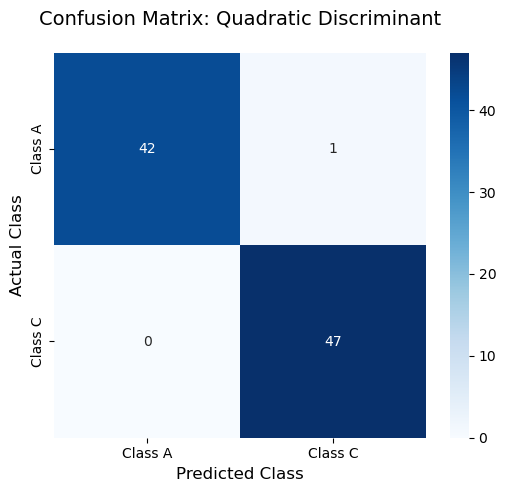

Accuracy: 0.9889
Balanced Accuracy: 0.9884
F1-Score: 0.9895




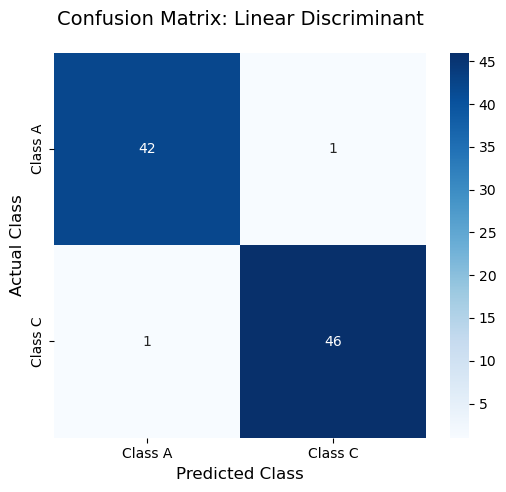

Accuracy: 0.9778
Balanced Accuracy: 0.9777
F1-Score: 0.9787




In [9]:
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score
import seaborn as sns

def model_results(expected, predicted, name):
    #calculating stats\
    cm = confusion_matrix(expected, predicted)
    accuracy = accuracy_score(expected, predicted)
    balanced_accuracy = balanced_accuracy_score(expected, predicted)
    f1 = f1_score(expected, predicted)

    #formating output
    #plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Class A', 'Class C'], 
                yticklabels=['Class A', 'Class C'])
    
    # 3. Add labels
    plt.title(f'Confusion Matrix: {name}', fontsize=14, pad=20)
    plt.ylabel('Actual Class', fontsize=12)
    plt.xlabel('Predicted Class', fontsize=12)
    plt.show()
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\n")

model_results(Y_test, y_pred_qda, "Quadratic Discriminant")
model_results(Y_test, y_pred_lda, "Linear Discriminant")